In [19]:
import numpy as np
from scipy.stats import cauchy, norm

cauchy_samples = cauchy.rvs(loc = 0, scale = 1, size = 10000)
normal_samples = norm.rvs(loc=0, scale = 1, size = 10000)

def calc_rolling_mean(x):
    return x.cumsum() / np.arange(1, len(x)+1)

def calc_rolling_std(x):
    # Welford's algorithm for rolling std (unbiased, ddof=1)
    n = np.arange(1, len(x)+1)
    mean = calc_rolling_mean(x)
    mean_sq = (x**2).cumsum() / n
    # variance = E[X^2] - (E[X])^2
    var = mean_sq - mean**2
    # For n > 1, use unbiased estimator (n/(n-1))
    var_unbiased = np.empty_like(var)
    var_unbiased[0] = np.nan
    var_unbiased[1:] = var[1:] * n[1:] / (n[1:]-1)
    return np.sqrt(var_unbiased)

cauchy_mean = calc_rolling_mean(cauchy_samples)
normal_mean = calc_rolling_mean(normal_samples)
cauchy_std = calc_rolling_std(cauchy_samples)
normal_std = calc_rolling_std(normal_samples)

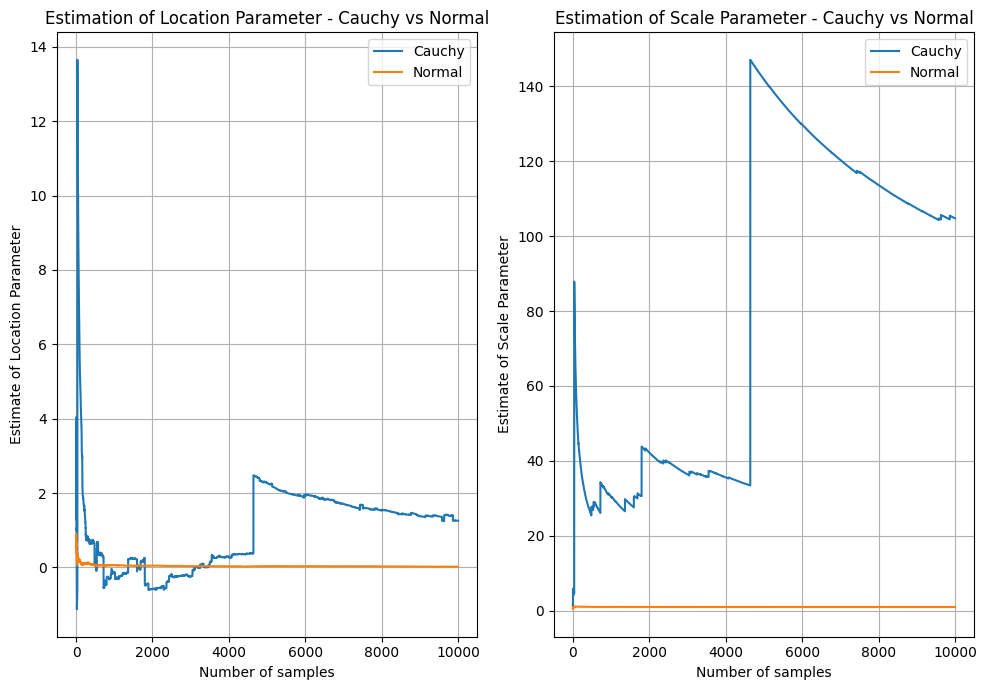

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 7))

ax[0].plot(cauchy_mean, label = 'Cauchy')
ax[0].plot(normal_mean, label='Normal')
ax[0].set_title('Estimation of Location Parameter - Cauchy vs Normal')
ax[0].set_xlabel('Number of samples')
ax[0].set_ylabel('Estimate of Location Parameter')
ax[0].grid()
ax[0].legend()

ax[1].plot(cauchy_std, label = 'Cauchy')
ax[1].plot(normal_std, label='Normal')
ax[1].set_title('Estimation of Scale Parameter - Cauchy vs Normal')
ax[1].set_xlabel('Number of samples')
ax[1].set_ylabel('Estimate of Scale Parameter')

ax[1].grid()
ax[1].legend()
plt.tight_layout()
plt.show()

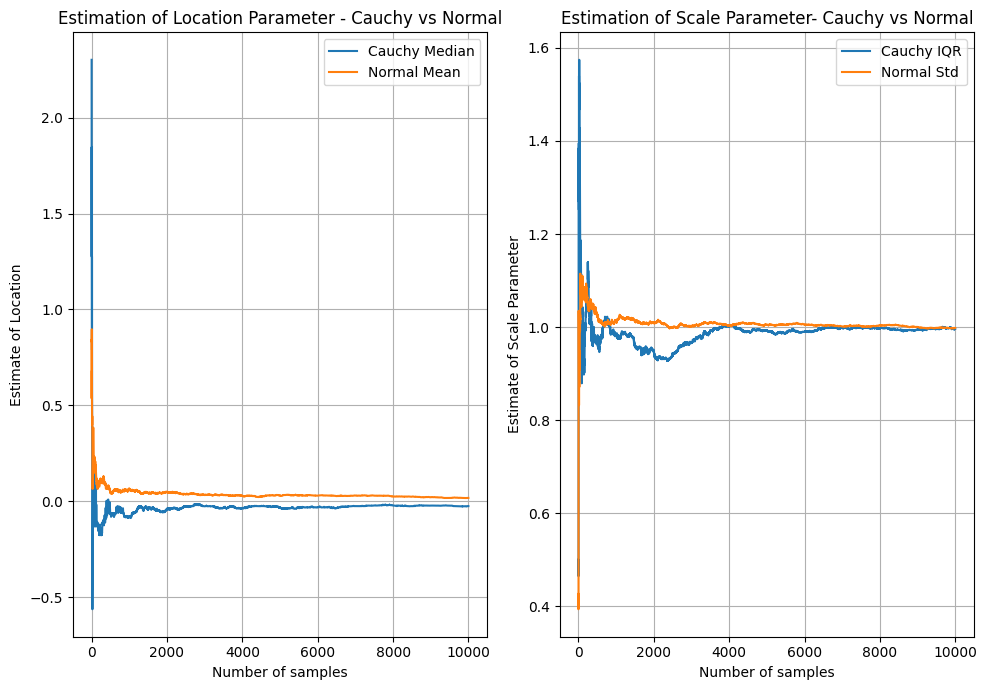

In [37]:
import matplotlib.pyplot as plt

def calc_rolling_median(x):
    return np.array([np.median(x[:i]) for i in range(1, len(x)+1)])

def calc_rolling_iqr(x):
    return np.array([np.subtract(*np.percentile(x[:i], [75, 25])) if i > 1 else np.nan for i in range(1, len(x)+1)])

cauchy_median = calc_rolling_median(cauchy_samples)
# normal_median = calc_rolling_median(normal_samples)
cauchy_iqr = calc_rolling_iqr(cauchy_samples)
# normal_iqr = calc_rolling_iqr(normal_samples)

fig, ax = plt.subplots(1, 2, figsize=(10, 7))
# Plot rolling median
ax[0].plot(cauchy_median, label='Cauchy Median')
ax[0].plot(normal_mean, label='Normal Mean')
ax[0].set_title('Estimation of Location Parameter - Cauchy vs Normal')
ax[0].set_xlabel('Number of samples')
ax[0].set_ylabel('Estimate of Location')
ax[0].legend()
ax[0].grid(True)


# Plot rolling IQR
ax[1].plot(cauchy_iqr / 2, label='Cauchy IQR')
ax[1].plot(normal_std, label='Normal Std')
ax[1].set_title('Estimation of Scale Parameter- Cauchy vs Normal')
ax[1].set_xlabel('Number of samples')
ax[1].set_ylabel('Estimate of Scale Parameter')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
normalised_cauchy_samples = cauchy_samples - cauchy_median
calc_rolling_iqr()

In [34]:
cauchy.fit(cauchy_samples)

(np.float64(-0.015054224832015975), np.float64(1.0078218812135582))